In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from src.evaluation import evaluate
from src.features import cycle
from src._xgboost import search_params_v5
from src.visualization import plot_forecast_with_train, plot_forecast
from src.MultiVariateForecaster import MultiVariateForecaster
from skforecast.direct import ForecasterDirectMultiVariate
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df['is_anomaly'] = np.where(df['Дата'] <= '2021-05-17', 1, 0)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df
    
def fit_best_model(df_train, best_params, target_cols, exog_cols):
    xgb_params = {
        'n_estimators': best_params['n_estimators'],
        'learning_rate': best_params['learning_rate'],
        'max_depth': best_params['max_depth'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'colsample_bylevel': best_params['colsample_bylevel'],
        'colsample_bynode': best_params['colsample_bynode'],
        'reg_alpha': best_params['reg_alpha'],
        'reg_lambda': best_params['reg_lambda'],
        'gamma': best_params['gamma'],
        'min_child_weight': best_params['min_child_weight'],
        'max_delta_step': best_params['max_delta_step'],
        'random_state': 42,
        'verbosity': 0,
        'n_jobs': -1
    }
    
    models = []
    for i in range(0, len(target_cols)):
        col = target_cols[i]
        lags_dict = {c: None for c in target_cols}
        lags_dict[col] = best_params[f'lags_{col}']
        if i != 0:
            neighbor_col = target_cols[i - 1]
            lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}_up']
        if i != len(target_cols) - 1:
            neighbor_col = target_cols[i + 1]
            lags_dict[neighbor_col] = best_params[f'neighbor_lags_{col}_down']
        models.append(ForecasterDirectMultiVariate(estimator=xgb.XGBRegressor(**xgb_params),
                                                level = col,
                                                steps = 1,
                                                lags = lags_dict))       
        
    forecaster = MultiVariateForecaster(models)
    forecaster.fit(df_train[target_cols], exog=df_train[exog_cols])
    
    return forecaster

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

In [6]:
model_path = f'../xgboost/models/xgb_v6'
target_cols = ['48-1 (0)','48-1 (1)','48-1 (2)', '48-1 (3)', '48-1 (4)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', '48-1 (9)', '48-1 (10)']
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_anomaly']

In [10]:
study = search_params_v5(df_train, df_val, target_cols, exog_cols=exog_cols, n_trials=10)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-22 18:39:33,186] A new study created in memory with name: no-name-8728f74a-8d2e-4298-95e3-10088459c666
[I 2026-05-22 18:39:42,382] Trial 0 finished with value: 0.4398606981714841 and parameters: {'n_estimators': 640, 'learning_rate': 0.03763630041851847, 'max_depth': 4, 'subsample': 0.9188416024569762, 'colsample_bytree': 0.7014629036921716, 'colsample_bylevel': 0.8437348510691027, 'colsample_bynode': 0.7753949763752486, 'reg_alpha': 0.004839773670465164, 'reg_lambda': 0.00012742499051241607, 'gamma': 0.13306733618229125, 'min_child_weight': 6, 'max_delta_step': 8, 'lags_48-1 (0)': 1, 'neighbor_lags_48-1 (0)_down': 1, 'lags_48-1 (1)': 4, 'neighbor_lags_48-1 (1)_up': 2, 'neighbor_lags_48-1 (1)_down': 1, 'lags_48-1 (2)': 4, 'neighbor_lags_48-1 (2)_up': 1, 'neighbor_lags_48-1 (2)_down': 1, 'lags_48-1 (3)': 5, 'neighbor_lags_48-1 (3)_up': 3, 'neighbor_lags_48-1 (3)_down': 1, 'lags_48-1 (4)': 1, 'neighbor_lags_48-1 (4)_up': 1, 'neighbor_lags_48-1 (4)_down': 1, 'lags_48-1 (5)': 1,

Лучшие параметры = {'n_estimators': 463, 'learning_rate': 0.0195302603292143, 'max_depth': 4, 'subsample': 0.4652201345267207, 'colsample_bytree': 0.9767054739714908, 'colsample_bylevel': 0.9651794361752416, 'colsample_bynode': 0.4706006447963445, 'reg_alpha': 0.0006683003724487987, 'reg_lambda': 0.1844490930524431, 'gamma': 2.500472548765431e-05, 'min_child_weight': 8, 'max_delta_step': 9, 'lags_48-1 (0)': 2, 'neighbor_lags_48-1 (0)_down': 2, 'lags_48-1 (1)': 3, 'neighbor_lags_48-1 (1)_up': 1, 'neighbor_lags_48-1 (1)_down': 1, 'lags_48-1 (2)': 3, 'neighbor_lags_48-1 (2)_up': 3, 'neighbor_lags_48-1 (2)_down': 1, 'lags_48-1 (3)': 1, 'neighbor_lags_48-1 (3)_up': 2, 'neighbor_lags_48-1 (3)_down': 1, 'lags_48-1 (4)': 3, 'neighbor_lags_48-1 (4)_up': 1, 'neighbor_lags_48-1 (4)_down': 1, 'lags_48-1 (5)': 5, 'neighbor_lags_48-1 (5)_up': 2, 'neighbor_lags_48-1 (5)_down': 3, 'lags_48-1 (6)': 4, 'neighbor_lags_48-1 (6)_up': 2, 'neighbor_lags_48-1 (6)_down': 2, 'lags_48-1 (7)': 1, 'neighbor_lags_4

In [11]:
model = fit_best_model(df_train, best_params, target_cols, exog_cols)
joblib.dump(model, model_path)

['../xgboost/models/xgb_v6']

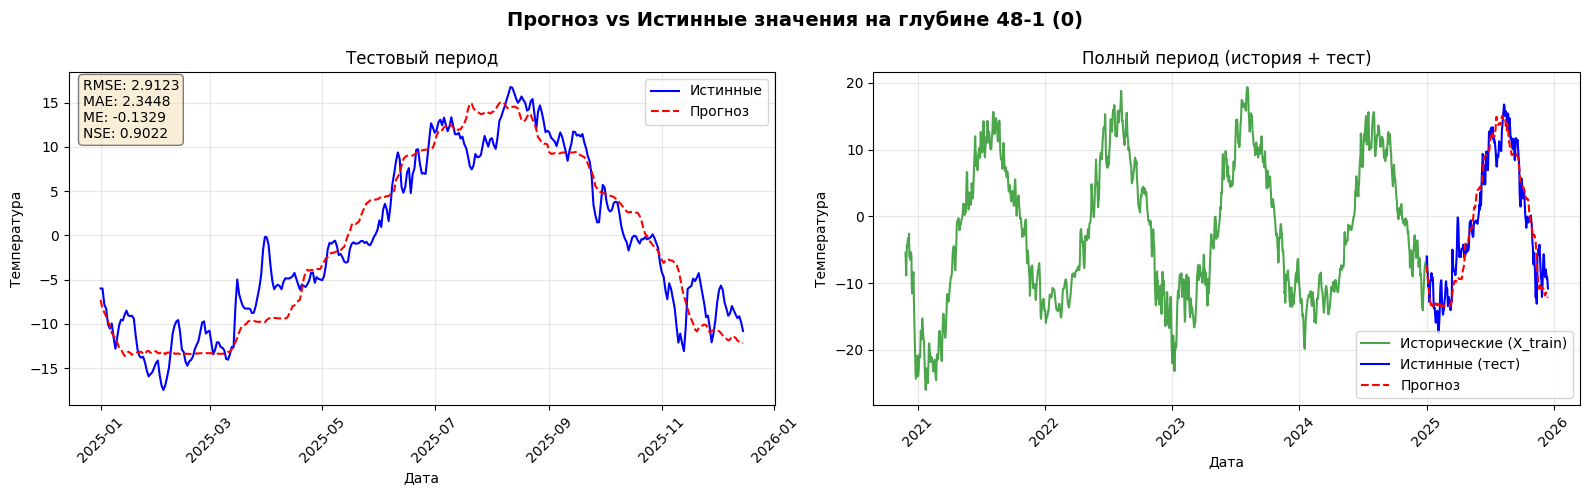

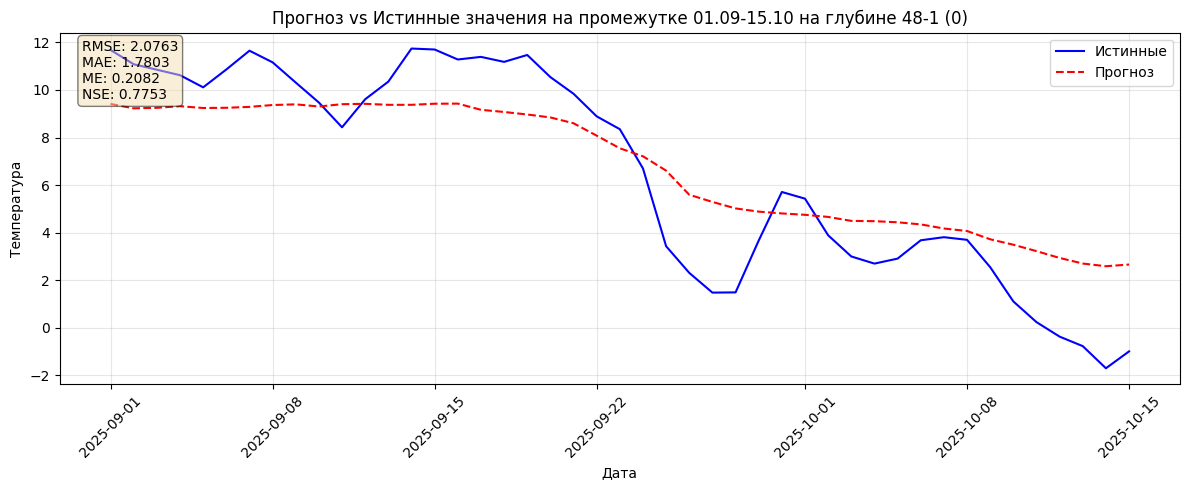

           feature  importance
5        Месяц_cos    0.446450
0   48-1 (0)_lag_1    0.167011
1   48-1 (0)_lag_2    0.145321
7  day_of_year_cos    0.062840
2   48-1 (1)_lag_1    0.057900
3   48-1 (1)_lag_2    0.055185
8       is_anomaly    0.028580
4        Месяц_sin    0.019569
6  day_of_year_sin    0.017145


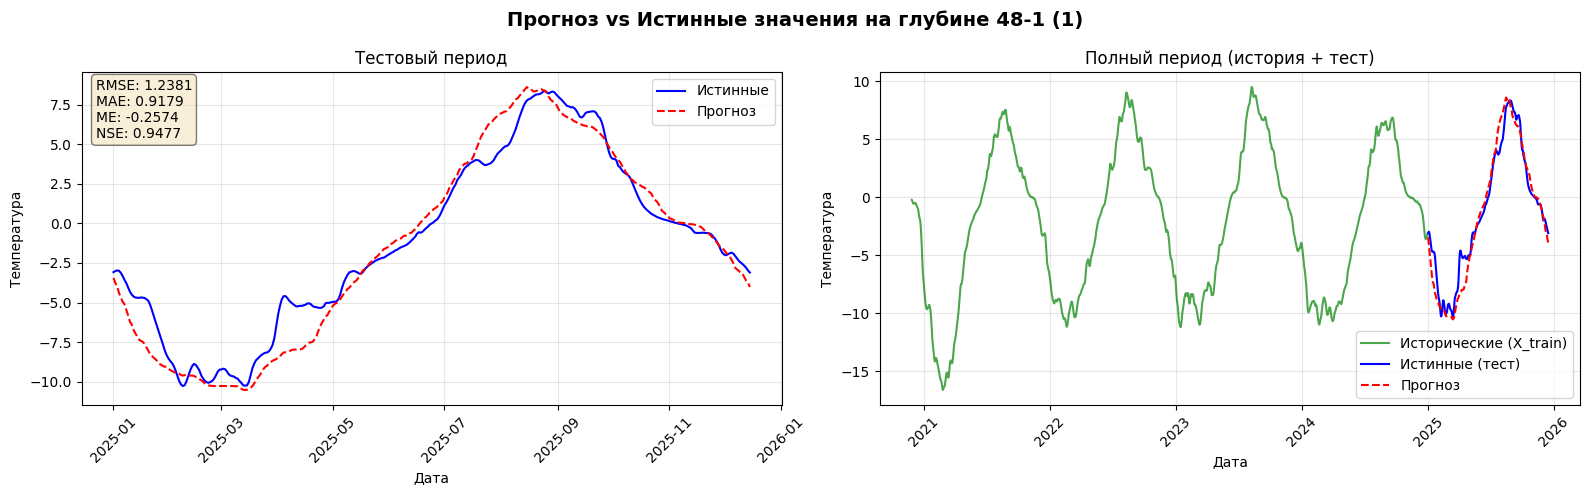

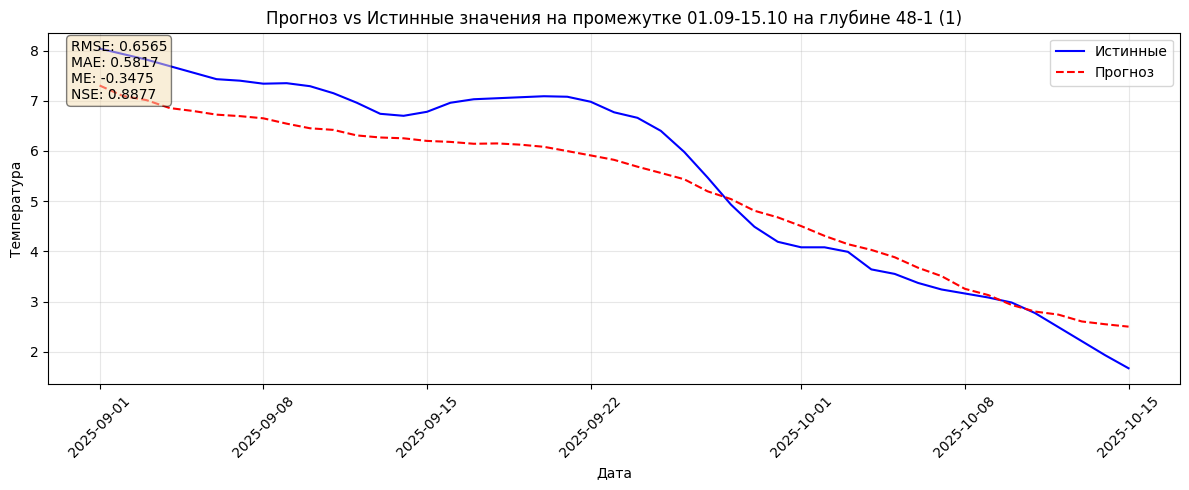

           feature  importance
3   48-1 (1)_lag_3    0.249220
1   48-1 (1)_lag_1    0.173002
4   48-1 (2)_lag_1    0.137281
2   48-1 (1)_lag_2    0.134676
7  day_of_year_sin    0.114952
6        Месяц_cos    0.085430
0   48-1 (0)_lag_1    0.041650
8  day_of_year_cos    0.028635
9       is_anomaly    0.026775
5        Месяц_sin    0.008379


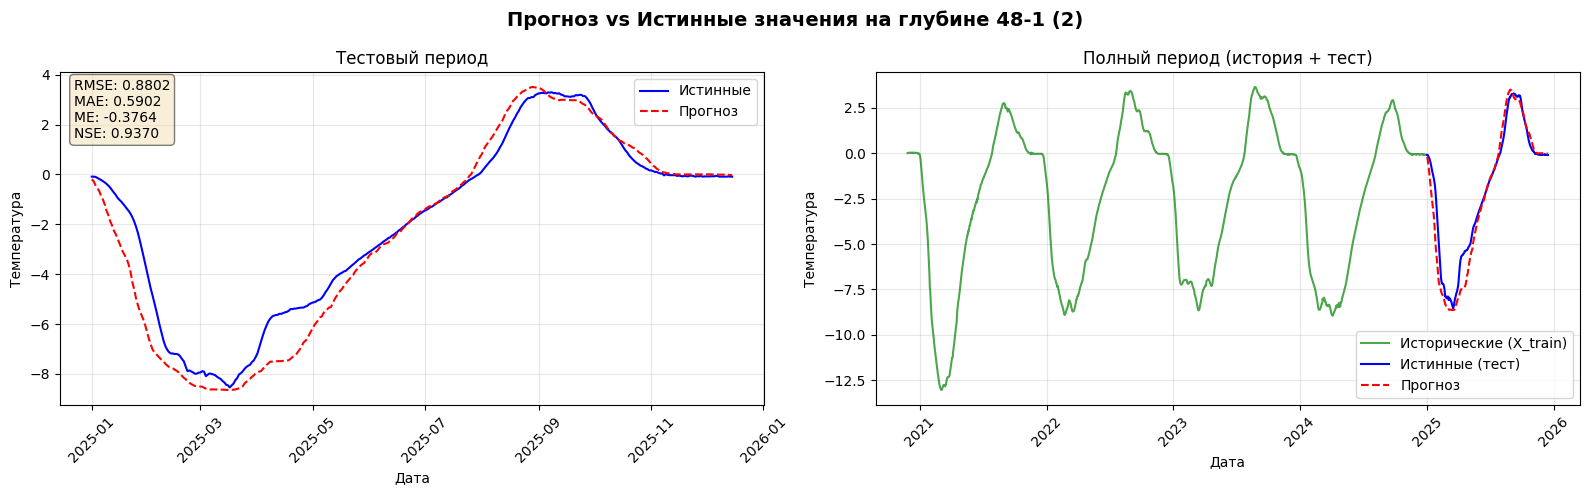

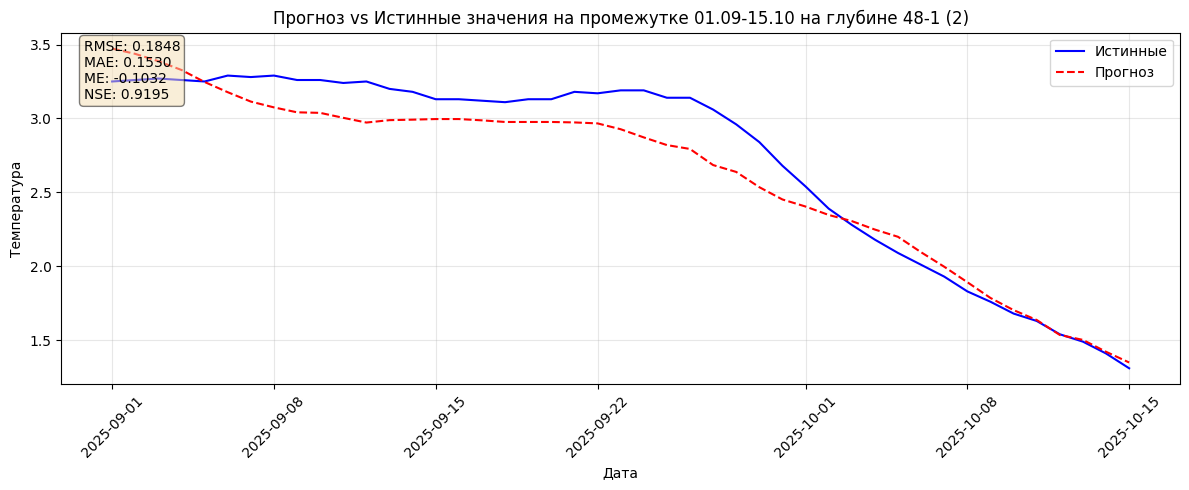

            feature  importance
3    48-1 (2)_lag_1    0.235998
4    48-1 (2)_lag_2    0.200395
5    48-1 (2)_lag_3    0.195365
6    48-1 (3)_lag_1    0.182510
9   day_of_year_sin    0.057582
7         Месяц_sin    0.042244
0    48-1 (1)_lag_1    0.029328
2    48-1 (1)_lag_3    0.026162
8         Месяц_cos    0.010933
1    48-1 (1)_lag_2    0.010491
10  day_of_year_cos    0.008029
11       is_anomaly    0.000962


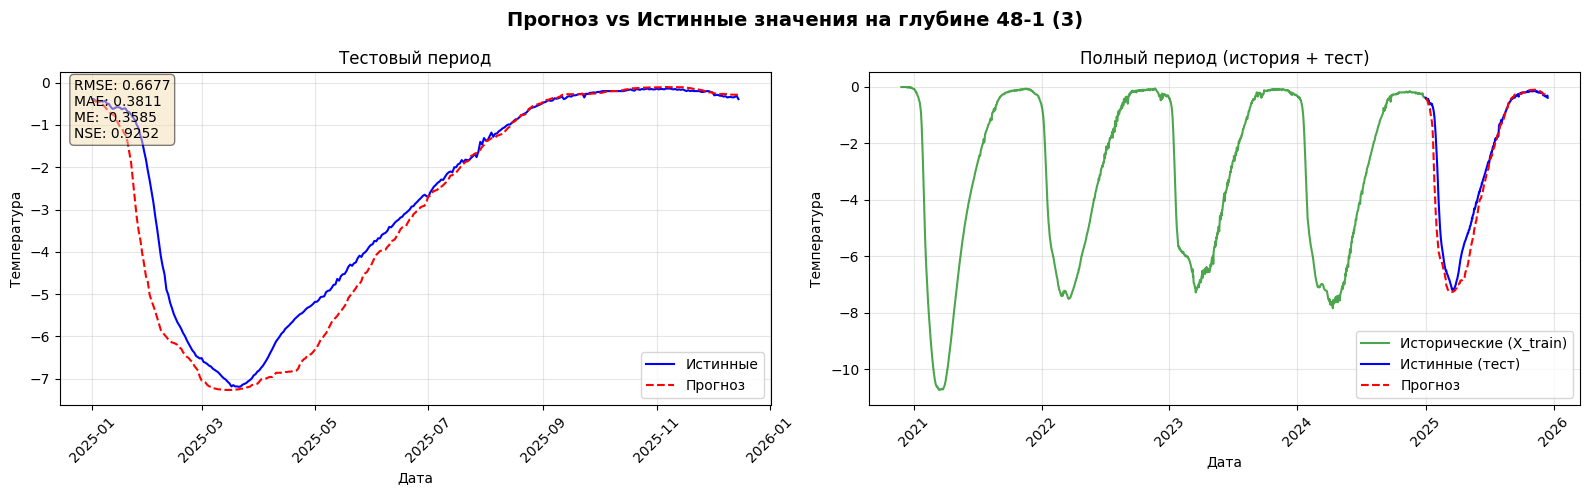

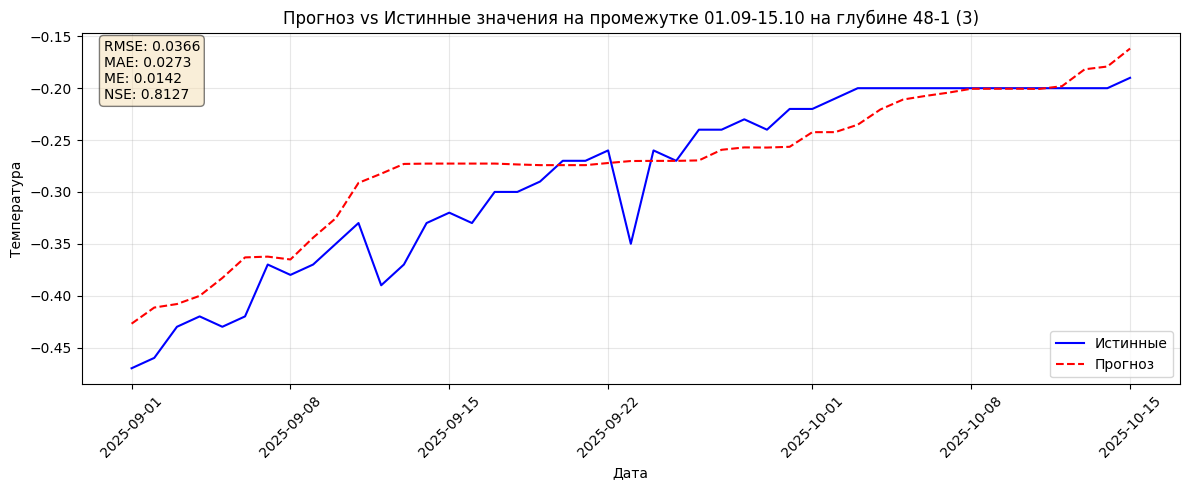

           feature  importance
2   48-1 (3)_lag_1    0.272285
3   48-1 (4)_lag_1    0.202847
6  day_of_year_sin    0.147767
0   48-1 (2)_lag_1    0.116825
4        Месяц_sin    0.114608
1   48-1 (2)_lag_2    0.085341
7  day_of_year_cos    0.027393
8       is_anomaly    0.022915
5        Месяц_cos    0.010020


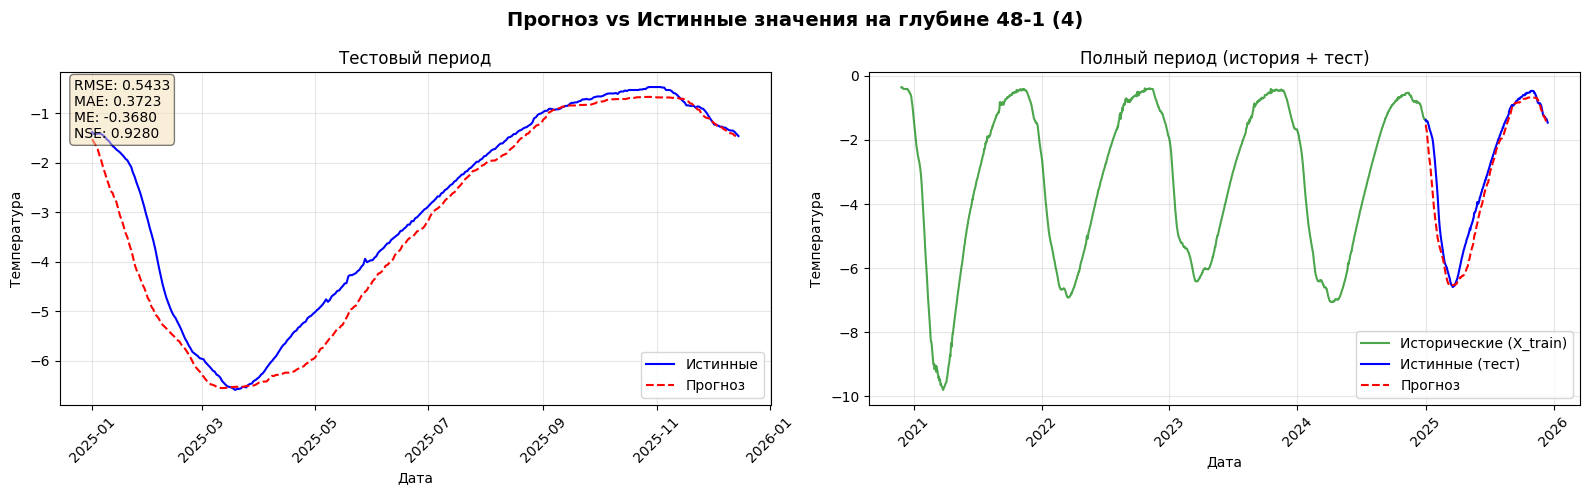

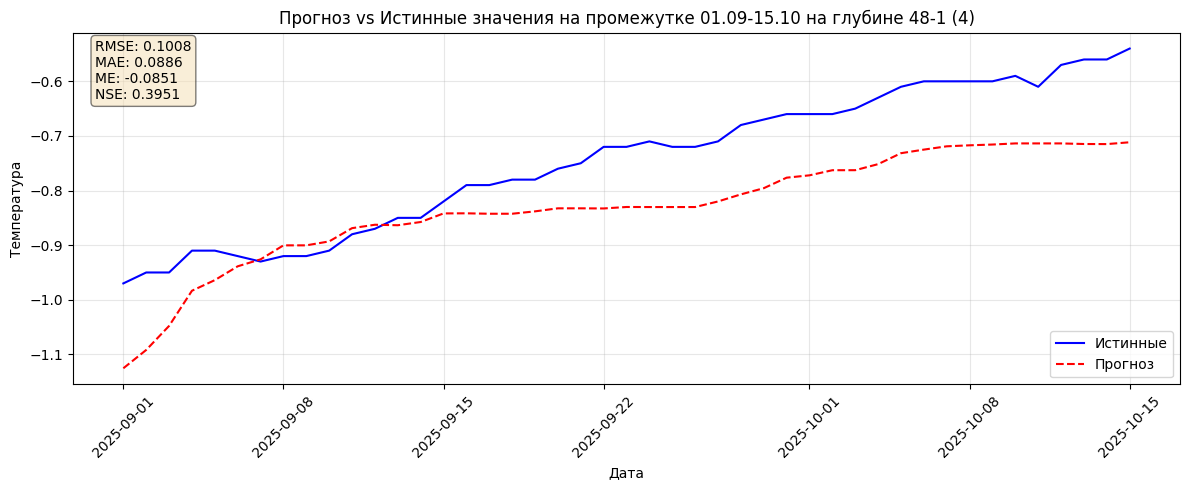

           feature  importance
4   48-1 (5)_lag_1    0.259763
3   48-1 (4)_lag_3    0.186718
1   48-1 (4)_lag_1    0.158303
7  day_of_year_sin    0.156357
2   48-1 (4)_lag_2    0.105984
5        Месяц_sin    0.070100
0   48-1 (3)_lag_1    0.041561
9       is_anomaly    0.017848
6        Месяц_cos    0.002003
8  day_of_year_cos    0.001364


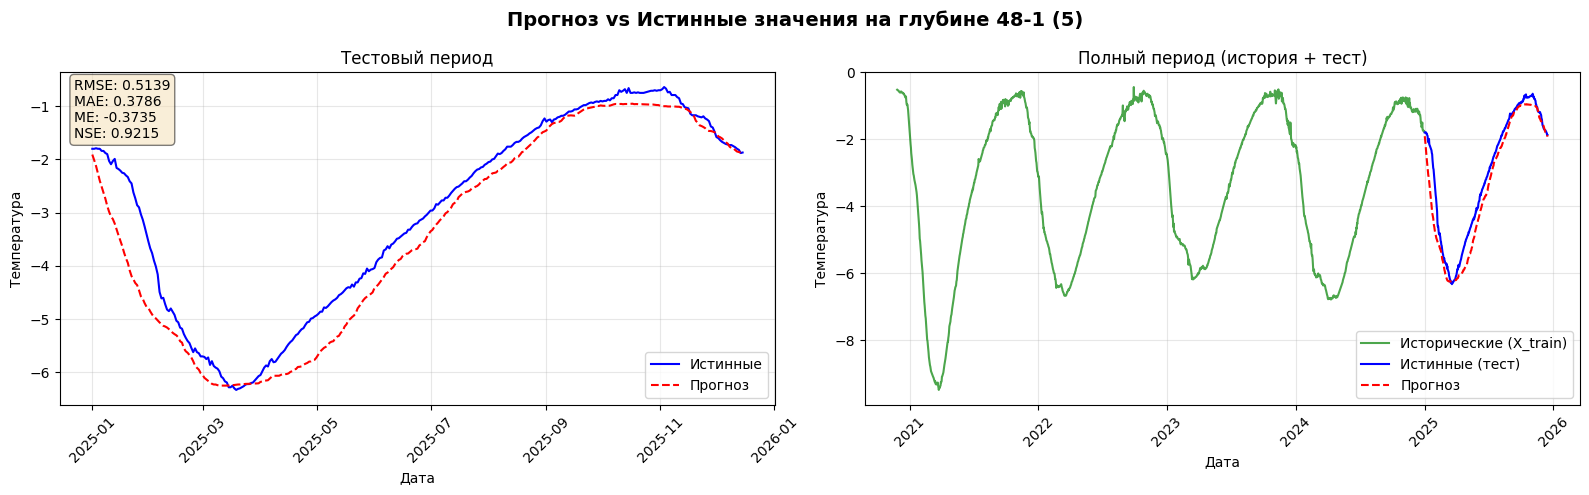

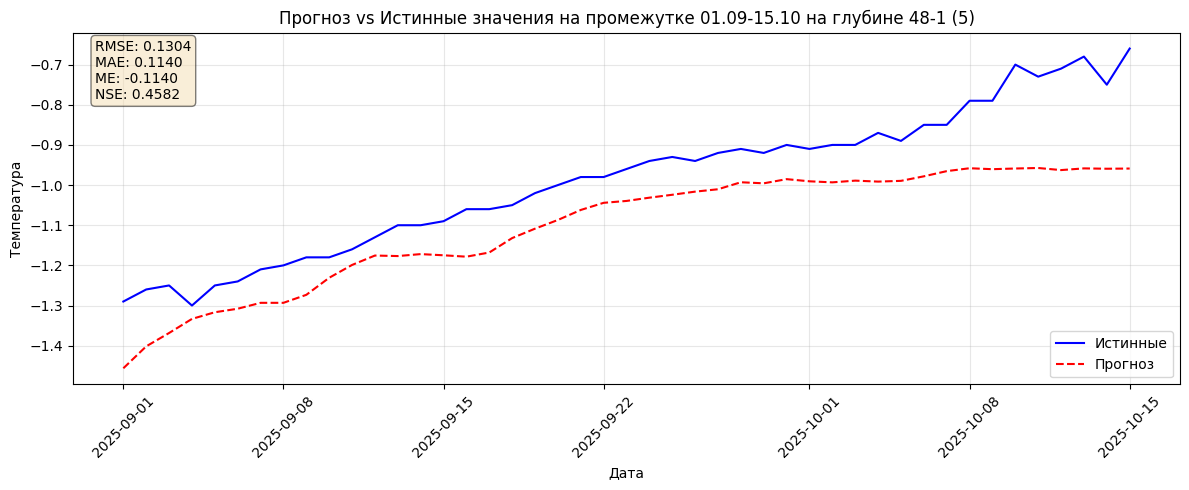

            feature  importance
8    48-1 (6)_lag_2    0.261232
9    48-1 (6)_lag_3    0.237577
7    48-1 (6)_lag_1    0.183537
2    48-1 (5)_lag_1    0.096864
3    48-1 (5)_lag_2    0.086757
0    48-1 (4)_lag_1    0.058919
4    48-1 (5)_lag_3    0.044399
1    48-1 (4)_lag_2    0.024042
5    48-1 (5)_lag_4    0.003801
12  day_of_year_sin    0.001007
14       is_anomaly    0.000783
10        Месяц_sin    0.000406
11        Месяц_cos    0.000336
13  day_of_year_cos    0.000260
6    48-1 (5)_lag_5    0.000077


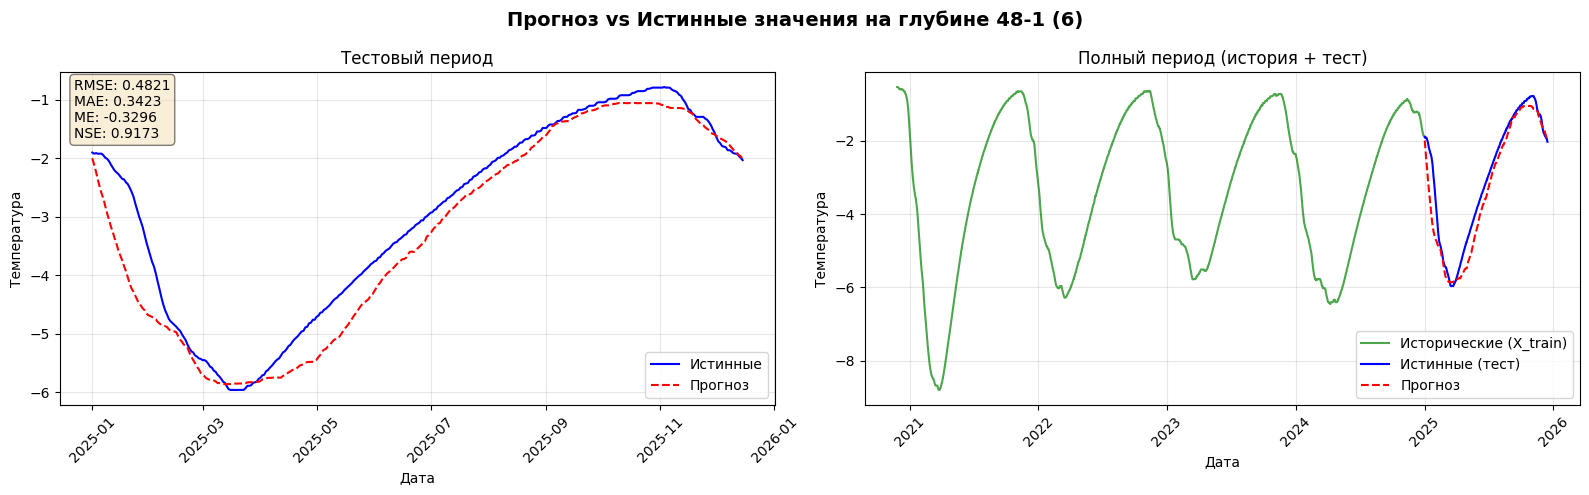

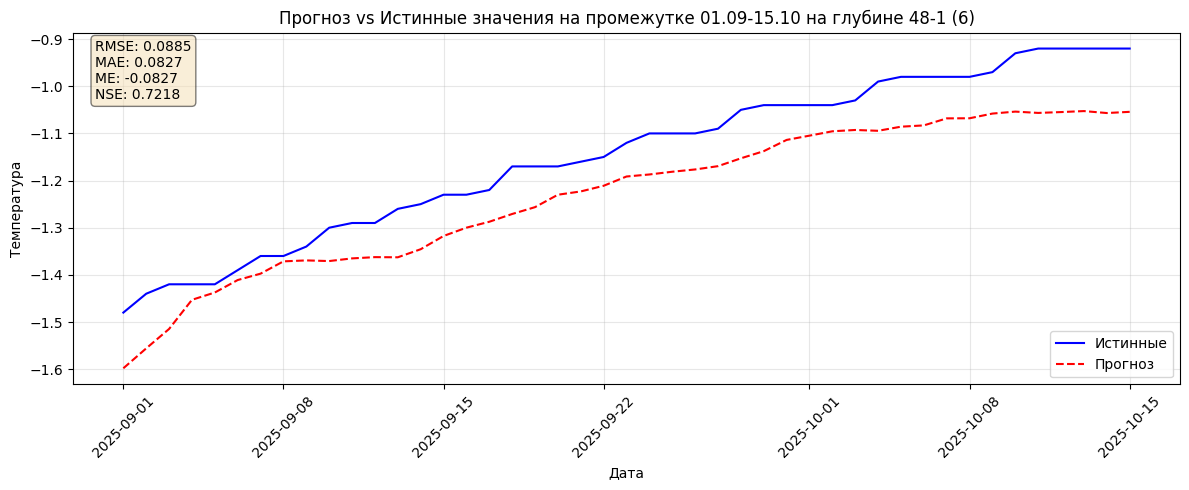

            feature  importance
7    48-1 (7)_lag_2    0.341861
6    48-1 (7)_lag_1    0.193671
2    48-1 (6)_lag_1    0.168861
3    48-1 (6)_lag_2    0.110470
0    48-1 (5)_lag_1    0.100610
1    48-1 (5)_lag_2    0.040697
4    48-1 (6)_lag_3    0.038701
10  day_of_year_sin    0.001819
5    48-1 (6)_lag_4    0.001678
12       is_anomaly    0.000616
9         Месяц_cos    0.000388
11  day_of_year_cos    0.000378
8         Месяц_sin    0.000252


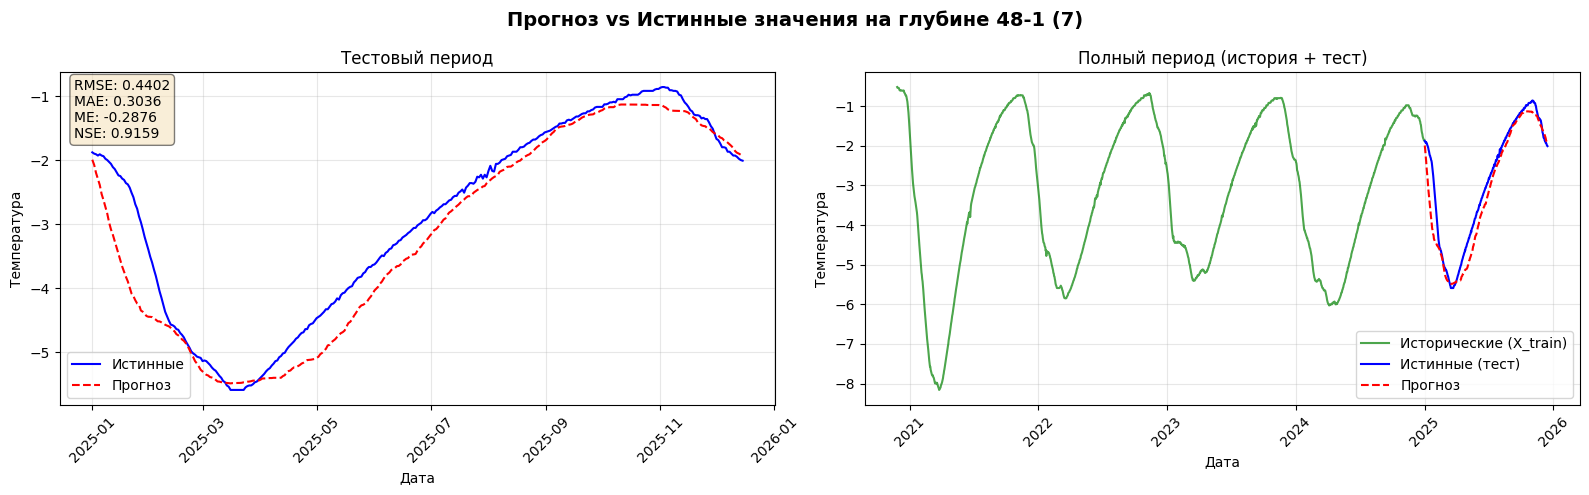

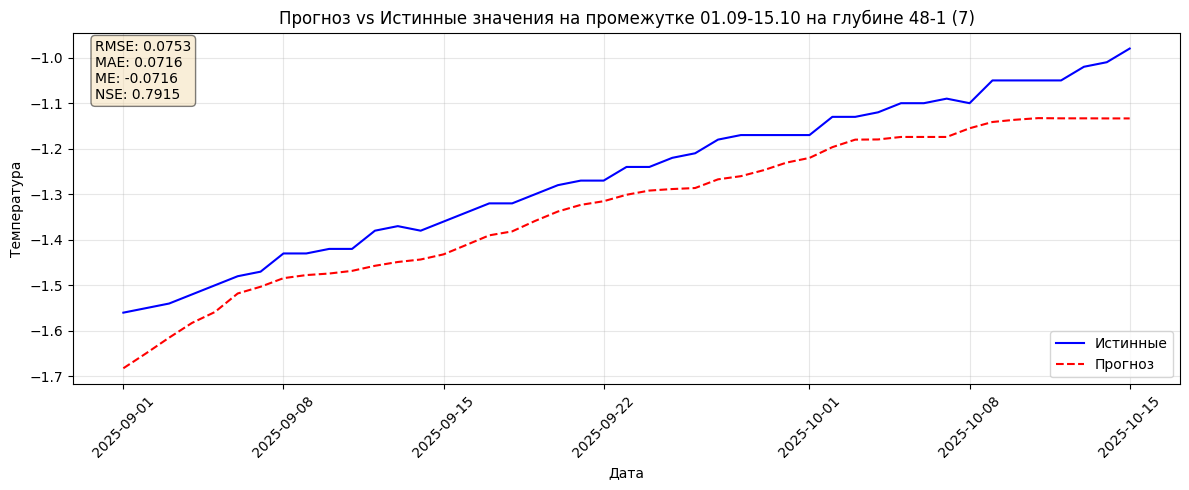

            feature  importance
2    48-1 (7)_lag_1    0.247048
0    48-1 (6)_lag_1    0.215387
4    48-1 (8)_lag_2    0.161015
3    48-1 (8)_lag_1    0.137553
1    48-1 (6)_lag_2    0.134293
5    48-1 (8)_lag_3    0.069415
8   day_of_year_sin    0.017922
6         Месяц_sin    0.014196
9   day_of_year_cos    0.001255
10       is_anomaly    0.001225
7         Месяц_cos    0.000692


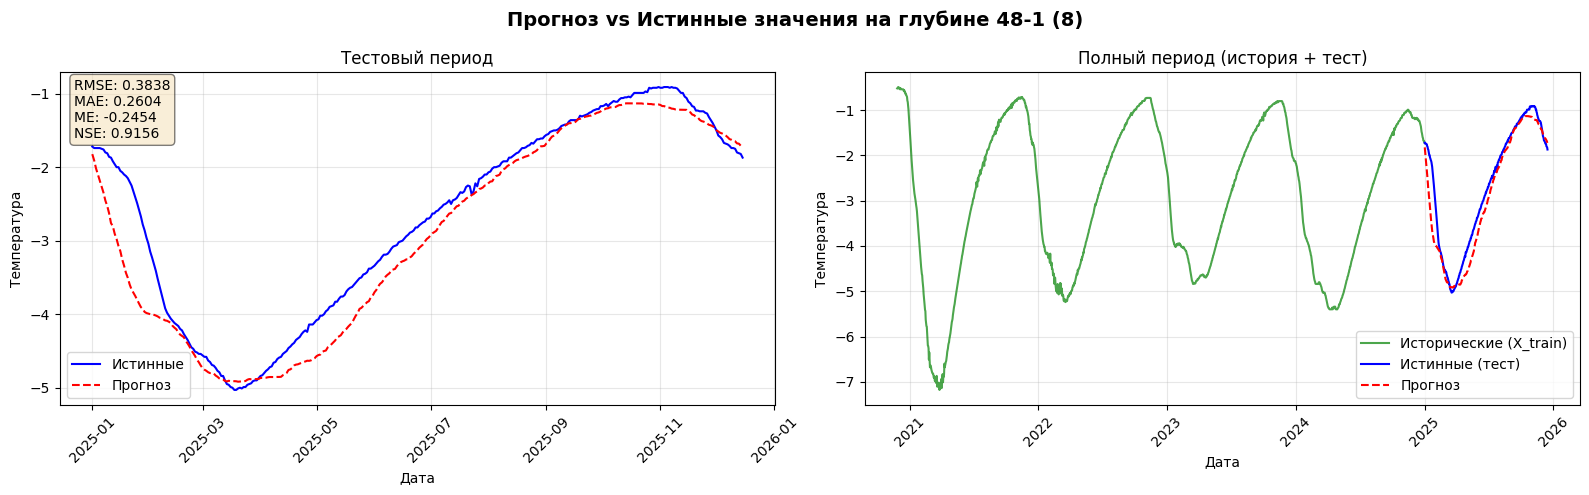

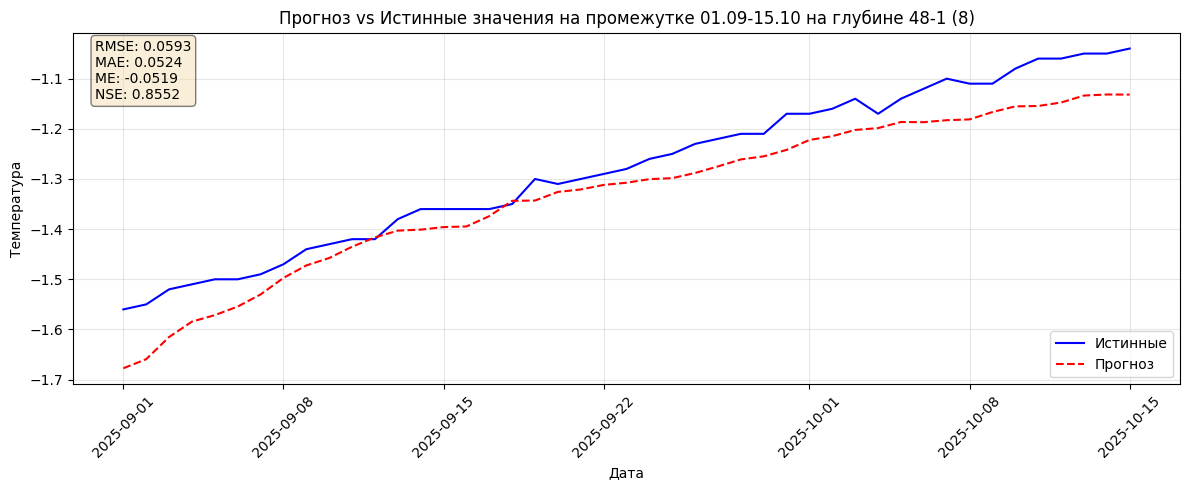

            feature  importance
2    48-1 (8)_lag_2    0.229106
1    48-1 (8)_lag_1    0.196010
0    48-1 (7)_lag_1    0.196008
3    48-1 (8)_lag_3    0.144805
4    48-1 (9)_lag_1    0.097737
9   day_of_year_sin    0.062941
5    48-1 (9)_lag_2    0.053991
6    48-1 (9)_lag_3    0.014258
11       is_anomaly    0.001828
7         Месяц_sin    0.001548
10  day_of_year_cos    0.001022
8         Месяц_cos    0.000747


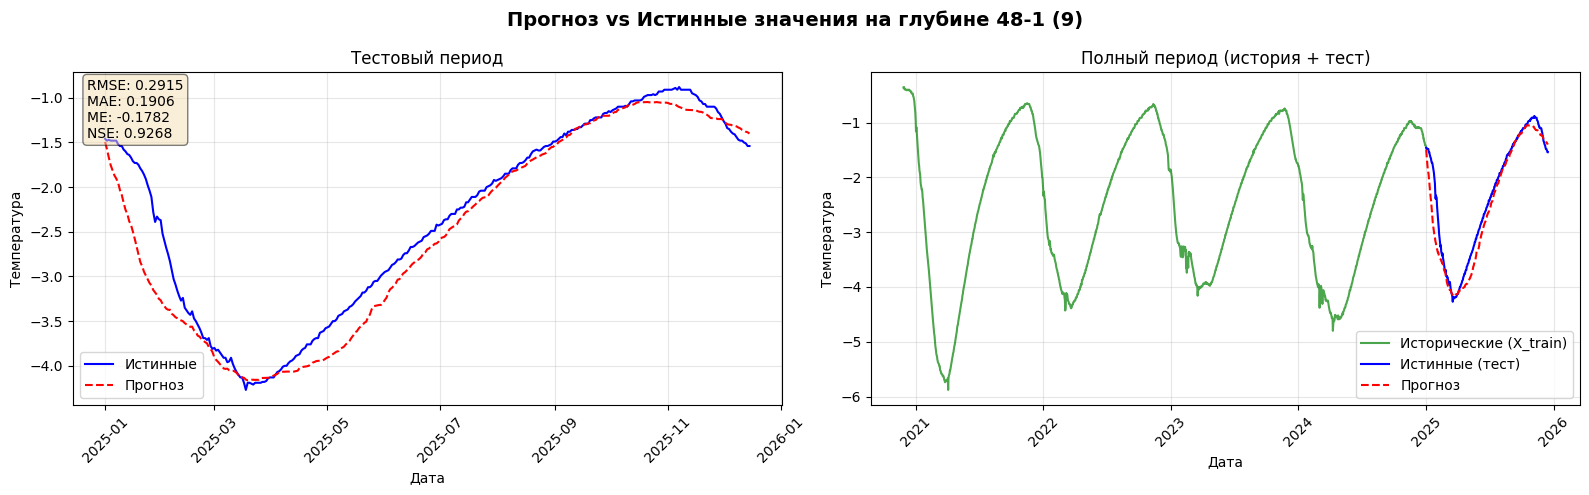

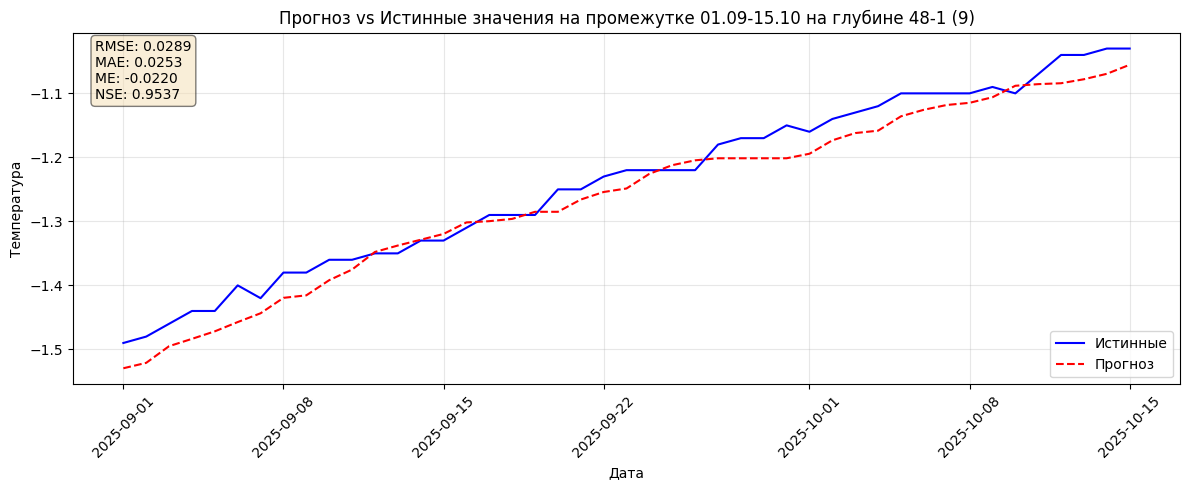

            feature  importance
1    48-1 (9)_lag_1    0.277760
2    48-1 (9)_lag_2    0.202956
0    48-1 (8)_lag_1    0.142461
4   48-1 (10)_lag_2    0.110791
8   day_of_year_sin    0.094982
3   48-1 (10)_lag_1    0.079275
5   48-1 (10)_lag_3    0.062087
6         Месяц_sin    0.024952
10       is_anomaly    0.002490
7         Месяц_cos    0.001272
9   day_of_year_cos    0.000972


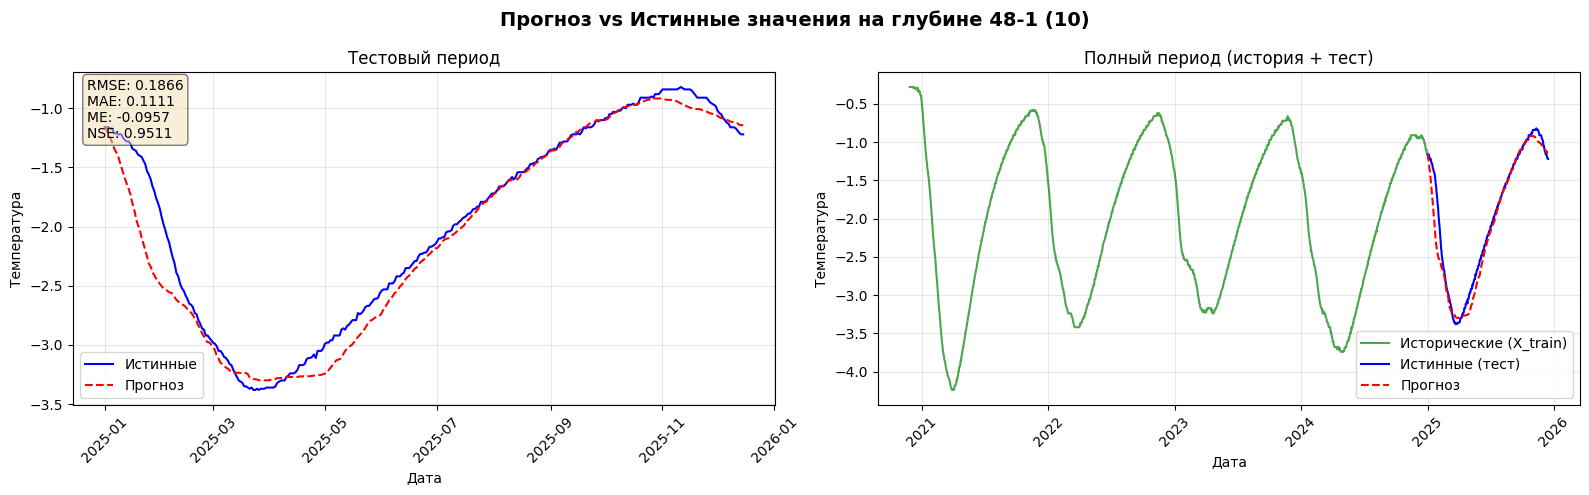

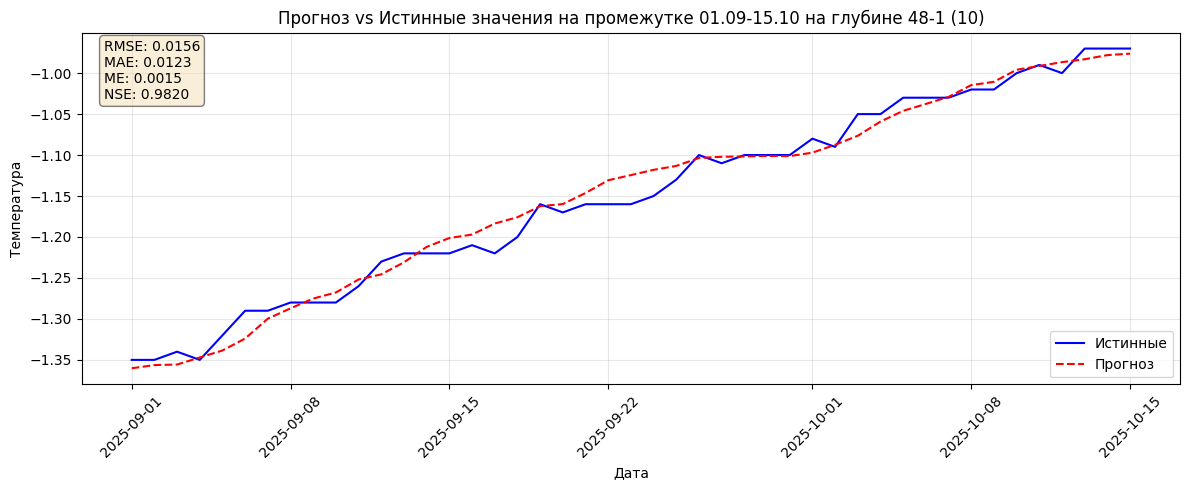

            feature  importance
3   48-1 (10)_lag_2    0.197431
2   48-1 (10)_lag_1    0.193544
4   48-1 (10)_lag_3    0.178700
1    48-1 (9)_lag_2    0.142945
5   48-1 (10)_lag_4    0.135931
0    48-1 (9)_lag_1    0.095545
6   48-1 (10)_lag_5    0.046513
9   day_of_year_sin    0.007747
7         Месяц_sin    0.000707
11       is_anomaly    0.000495
10  day_of_year_cos    0.000225
8         Месяц_cos    0.000219


In [7]:
model = joblib.load(model_path)
predicts = model.predict(len(df_test), df_train_full[target_cols], exog=df_test[exog_cols])
predicts.index = df_test.index
for col in target_cols:
    y_pred = predicts[col]
    y_true = df_test[col]
    
    metrics = evaluate(y_true.values, y_pred.values)
    
    y_pred_autumn = y_pred['2025-09-01':'2025-10-15']
    metrics_autumn = evaluate(y_true['2025-09-01':'2025-10-15'].values, y_pred_autumn.values)
    
    plot_forecast_with_train(df_train_full[col], pd.DataFrame(y_true), pd.DataFrame(y_pred), metrics_dict=metrics, title=f'Прогноз vs Истинные значения на глубине {col}')
    plot_forecast(pd.DataFrame(y_true['2025-09-01':'2025-10-15']), pd.DataFrame(y_pred_autumn), metrics_dict=metrics_autumn, title=f'Прогноз vs Истинные значения на промежутке 01.09-15.10 на глубине {col}')
    
    
    importances = model.forecasters[col].get_feature_importances(step = 1)
    print(importances)